# Cartpole Isaac Lab PPO Demonstration

In this notebook, we are going to use Isaac Lab to run PPO on cartpole. In order to fully understand this system we are going to discuss the 
- environment
- neural network architecture
- reinforcement learning algorithm
in some depth. 

The important goal is to try to make this system as simple as possible.

Let's begin by importing and launching the sim. First we will launch Isaac lab using our custom api wrapper, then 

In [ ]:
# launch Isaac Sim first (before any other isaaclab import). One env per kernel: restart to switch tasks.
from api import isaac

app = isaac.launch(cameras=True)

The Cartpole environment. Cartpole sets up a Markov Decision Process (MDP) $(S, A, P, R, \gamma)$
- $S = \mathbb{R}^4$ (pole angle, pole angular vel., cart position, cart vel.)
- $A = \mathbb{R}$ (force imposed on the cart with a unit of "centi-Newtons" - action of 1.0 leads to +100 N of force)
- $P$: just the transition function as given by Isaac's physics
- $R = 1.0 \cdot (1-d) \;-\; 2.0 \cdot d \;-\; 1.0 \cdot \theta^2 \;-\; 0.01 \cdot |\dot x| \;-\; 0.005, |\dot\theta|$  where $d$ is a boolean variable that is 1 if the episode fails

The discount for this envrionemtn is $\gamma=0.99$. This is used in training the value function. 


In [ ]:
import math
import time

import torch
import torch.nn as nn
from torch.distributions import Normal

TASK = "Isaac-Cartpole-Direct-v0"
NUM_ENVS = 4096


def side_camera(cfg):
    # camera on env 0 from the side: the rail runs along y, and env 0 sits at the +x corner of the grid, so viewing
    # from +x keeps the other 4095 cartpoles behind it
    cfg.viewer.origin_type = "env"
    cfg.viewer.eye = (5.0, 0.0, 2.5)
    cfg.viewer.lookat = (0.0, 0.0, 2.0)


env = isaac.make_env(TASK, num_envs=NUM_ENVS, render=True, cfg_fn=side_camera)
cfg = env.unwrapped.cfg

print("\nPrinting cfg:\n", cfg, "\n\n")
device = env.unwrapped.device
obs_dim, act_dim = cfg.observation_space, cfg.action_space
print(f"{TASK}: {NUM_ENVS} envs, obs {obs_dim}, act {act_dim}, control dt {env.unwrapped.step_dt:.4f}s, "
      f"episode {cfg.episode_length_s}s")

The neural network parameterization for our gaussian policy is quite simple. It is an MLP that look like 
$$\text{MLP}: \mathbb{R}^4 \rightarrow \mathbb{R}^{32} \rightarrow \mathbb{R}^{32} \rightarrow \mathbb{R}$$
where the output is the state conditioned mean of the gaussian posteriro distritbnion $\mu(s) = \text{MLP}(s)$. For a full Gaussian policy, we also need a standard deviation $\sigma$. This is a *single parameter* itself that is *not* state conditioned. This is reported to make the dynamics easier to learn. 

In [3]:
# actor-critic: separate MLPs, state-independent Gaussian std (as in rsl_rl)
class ActorCritic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=(32, 32), init_std=1.0):
        super().__init__()

        def mlp(out_dim):
            layers, d = [], obs_dim
            for h in hidden:
                layers += [nn.Linear(d, h), nn.ELU()]
                d = h
            return nn.Sequential(*layers, nn.Linear(d, out_dim))

        self.actor = mlp(act_dim)
        self.critic = mlp(1)
        self.log_std = nn.Parameter(torch.full((act_dim,), math.log(init_std)))

    def dist(self, obs):
        return Normal(self.actor(obs), self.log_std.exp())

    def value(self, obs):
        return self.critic(obs).squeeze(-1)


ac = ActorCritic(obs_dim, act_dim).to(device)

### The PPO update

Advantages come from GAE, with $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$:
$$\hat A_t = \delta_t + \gamma \lambda \hat A_{t+1}$$

The policy maximizes the clipped objective, with $\rho_t = \pi_\theta(a_t \mid s_t) / \pi_{\text{old}}(a_t \mid s_t)$:
$$L^{\text{clip}} = \mathbb{E}_t\left[\min\left(\rho_t \hat A_t,\; \text{clip}(\rho_t, 1-\epsilon, 1+\epsilon)\, \hat A_t\right)\right]$$


The value function regresses onto $\hat A_t + V(s_t)$, and a small entropy bonus keeps $\sigma$ from shrinking too fast.

NOTE: The primary reason for the intricate clipping in PPO is to handle *off-policy* updates. That is, after a rollout the first gradient update yeilds $\rho=1$, so the above $L^\text{clip}$ objective is just the vanilla policy gradient. However if we apply further gradient steps (perhaps from mini-batching our gradient updates), we'll find that $\pi_\text{new}$ will have already drifted away from $\pi_\text{old}$ and we don't want to over update certain directions in "policy-space" so we add a clip to prevent furhter updates beyond a certain probability ratio.


In [4]:
# PPO hyperparameters: Isaac Lab's reference (isaaclab_tasks/direct/cartpole/agents/rsl_rl_ppo_cfg.py)
STEPS_PER_ENV = 16      # rollout length; batch = 16 * 4096 = 65536 transitions
ITERATIONS = 150
EPOCHS = 5
MINIBATCHES = 4
GAMMA, LAM = 0.99, 0.95
CLIP = 0.2
VALUE_COEF, ENTROPY_COEF = 1.0, 0.005
MAX_GRAD_NORM = 1.0
LR, DESIRED_KL = 1e-3, 0.01  # adaptive lr: shrink/grow lr to keep KL near DESIRED_KL

opt = torch.optim.Adam(ac.parameters(), lr=LR)


def gae(rewards, values, dones, last_value):
    """Generalized advantage estimation over a [T, N] rollout."""
    adv = torch.zeros_like(rewards)
    next_adv, next_value = 0.0, last_value
    for t in reversed(range(rewards.shape[0])):
        not_done = 1.0 - dones[t]
        delta = rewards[t] + GAMMA * not_done * next_value - values[t]
        next_adv = delta + GAMMA * LAM * not_done * next_adv
        adv[t] = next_adv
        next_value = values[t]
    return adv, adv + values


def ppo_update(obs, actions, old_logp, old_values, adv, returns):
    global LR
    n = obs.shape[0]
    stats = []
    for _ in range(EPOCHS):
        for idx in torch.randperm(n, device=device).chunk(MINIBATCHES):
            d = ac.dist(obs[idx])
            logp = d.log_prob(actions[idx]).sum(-1)
            a = adv[idx]
            a = (a - a.mean()) / (a.std() + 1e-8)

            # clipped surrogate objective
            ratio = torch.exp(logp - old_logp[idx])
            policy_loss = -torch.min(ratio * a, ratio.clamp(1 - CLIP, 1 + CLIP) * a).mean()

            # clipped value loss
            v = ac.value(obs[idx])
            v_clipped = old_values[idx] + (v - old_values[idx]).clamp(-CLIP, CLIP)
            value_loss = torch.max((v - returns[idx]) ** 2, (v_clipped - returns[idx]) ** 2).mean()

            entropy = d.entropy().sum(-1).mean()
            loss = policy_loss + VALUE_COEF * value_loss - ENTROPY_COEF * entropy

            # adaptive learning rate from approximate KL(old || new)
            with torch.no_grad():
                kl = ((ratio - 1) - torch.log(ratio)).mean().item()
            if kl > 2 * DESIRED_KL:
                LR = max(LR / 1.5, 1e-5)
            elif kl < DESIRED_KL / 2:
                LR = min(LR * 1.5, 1e-2)
            for g in opt.param_groups:
                g["lr"] = LR

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(ac.parameters(), MAX_GRAD_NORM)
            opt.step()
            stats.append((policy_loss.item(), value_loss.item(), entropy.item(), kl))
    return torch.tensor(stats).mean(0).tolist()

In [5]:
# training loop
T, N = STEPS_PER_ENV, NUM_ENVS
buf_obs = torch.zeros(T, N, obs_dim, device=device)
buf_act = torch.zeros(T, N, act_dim, device=device)
buf_logp, buf_val, buf_rew, buf_done = (torch.zeros(T, N, device=device) for _ in range(4))

ep_return = torch.zeros(N, device=device)
ep_length = torch.zeros(N, device=device)
history = {"iteration": [], "return": [], "length": [], "steps/s": []}

obs = env.reset()[0]["policy"]
for it in range(ITERATIONS):
    t0 = time.time()
    finished_returns, finished_lengths = [], []
    for t in range(T):
        with torch.no_grad():
            d = ac.dist(obs)
            action = d.sample()
            buf_logp[t] = d.log_prob(action).sum(-1)
            buf_val[t] = ac.value(obs)
        buf_obs[t], buf_act[t] = obs, action

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated | truncated
        # time-limit truncation is not failure: bootstrap with V(s) (rsl_rl's approximation)
        buf_rew[t] = reward + GAMMA * buf_val[t] * truncated.float()
        buf_done[t] = done.float()

        ep_return += reward
        ep_length += 1
        if done.any():
            finished_returns.append(ep_return[done])
            finished_lengths.append(ep_length[done])
            ep_return[done] = 0
            ep_length[done] = 0
        obs = next_obs["policy"]

    with torch.no_grad():
        adv, returns = gae(buf_rew, buf_val, buf_done, ac.value(obs))
    pl, vl, ent, kl = ppo_update(
        buf_obs.flatten(0, 1), buf_act.flatten(0, 1), buf_logp.flatten(), buf_val.flatten(),
        adv.flatten(), returns.flatten(),
    )

    if finished_returns:
        history["iteration"].append(it)
        history["return"].append(torch.cat(finished_returns).mean().item())
        history["length"].append(torch.cat(finished_lengths).mean().item())
        history["steps/s"].append(T * N / (time.time() - t0))
    if it % 10 == 0 or it == ITERATIONS - 1:
        r = history["return"][-1] if history["return"] else float("nan")
        print(f"it {it:4d} | return {r:7.2f} | ep len {history['length'][-1] if history['length'] else 0:5.1f} | "
              f"pi {pl:+.3f} v {vl:.3f} ent {ent:.2f} kl {kl:.4f} lr {LR:.1e} | "
              f"{T * N / (time.time() - t0):,.0f} steps/s")

it    0 | return   -5.32 | ep len  14.4 | pi -0.011 v 21.226 ent 1.42 kl 0.0093 lr 3.4e-03 | 76,450 steps/s
it   10 | return   33.56 | ep len  63.8 | pi -0.011 v 29.131 ent 1.32 kl 0.0115 lr 4.4e-03 | 139,034 steps/s
it   20 | return  138.47 | ep len 152.2 | pi -0.001 v 24.338 ent 1.05 kl 0.0018 lr 1.0e-02 | 125,184 steps/s
it   30 | return  155.59 | ep len 164.9 | pi +0.001 v 16.329 ent 0.84 kl 0.0033 lr 1.0e-02 | 131,555 steps/s
it   40 | return  166.64 | ep len 174.4 | pi +0.030 v 13.556 ent 0.77 kl 0.0404 lr 1.0e-05 | 140,061 steps/s
it   50 | return  259.36 | ep len 265.5 | pi +0.001 v 11.990 ent 0.60 kl 0.0046 lr 1.0e-02 | 133,527 steps/s
it   60 | return  288.00 | ep len 293.2 | pi -0.000 v 9.890 ent 0.51 kl 0.0033 lr 1.0e-02 | 129,670 steps/s
it   70 | return  294.20 | ep len 299.0 | pi +0.004 v 7.186 ent 0.46 kl 0.0078 lr 6.6e-03 | 135,531 steps/s
it   80 | return  294.50 | ep len 299.0 | pi -0.000 v 5.661 ent 0.43 kl 0.0021 lr 1.0e-02 | 126,613 steps/s
it   90 | return  293.0

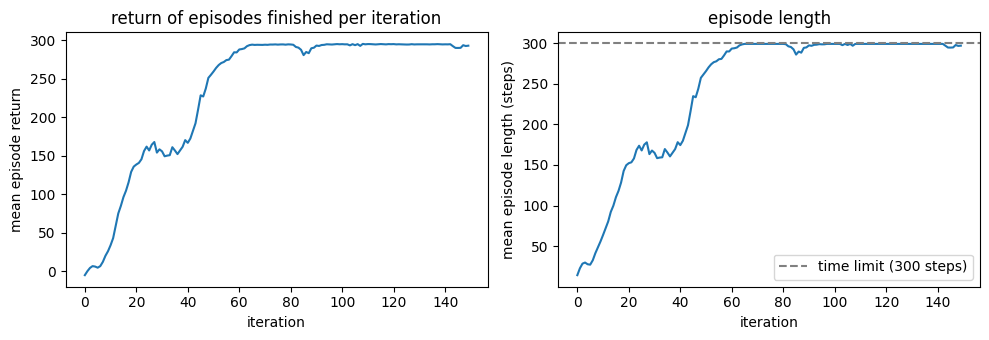

In [6]:
import matplotlib.pyplot as plt

max_len = int(cfg.episode_length_s / env.unwrapped.step_dt)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history["iteration"], history["return"])
axes[0].set(xlabel="iteration", ylabel="mean episode return", title="return of episodes finished per iteration")
axes[1].plot(history["iteration"], history["length"])
axes[1].axhline(max_len, color="gray", ls="--", label=f"time limit ({max_len} steps)")
axes[1].set(xlabel="iteration", ylabel="mean episode length (steps)", title="episode length")
axes[1].legend()
plt.tight_layout()
plt.show()

In [7]:
# deterministic rollout (policy mean) of the trained policy; video embedded in the notebook (no file left on disk)
from api.video import show

obs = env.reset()[0]["policy"]
frames = []
for _ in range(max_len):
    with torch.no_grad():
        obs = env.step(ac.actor(obs))[0]["policy"]
    frames.append(env.render())
show(frames, fps=round(1 / env.unwrapped.step_dt))